## Loading the dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10


In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

data_dir = os.path.join(path, 'raw-img')


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

print("Classes found:", full_dataset.classes)
print(f"Total images: {len(full_dataset)}")


train_size = int(0.8 * len(full_dataset))
valid_size = len(full_dataset) - train_size
train_dataset, valid_dataset = torch.utils.data.random_split(full_dataset, [train_size, valid_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

Using device: cpu
Classes found: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Total images: 26179


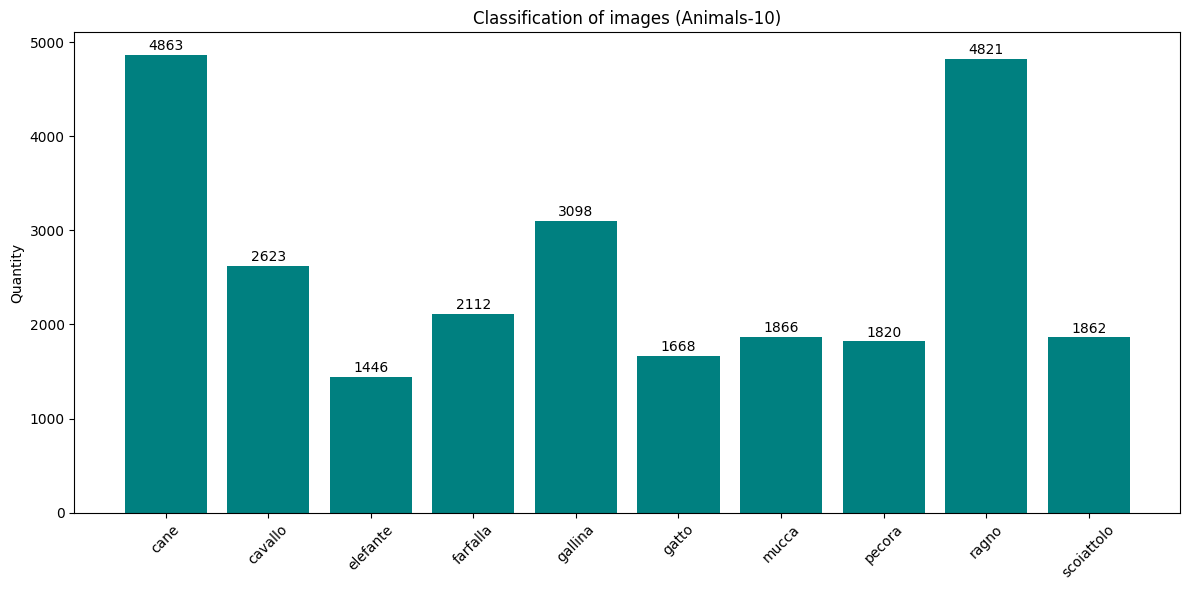

In [4]:
import matplotlib.pyplot as plt


labels = full_dataset.targets
class_names = full_dataset.classes


counts_dict = {}
for label_idx in labels:
    counts_dict[label_idx] = counts_dict.get(label_idx, 0) + 1


class_counts = [counts_dict[i] for i in range(len(class_names))]


plt.figure(figsize=(12, 6))
plt.bar(class_names, class_counts, color='teal')
plt.title('Classification of images (Animals-10)')
plt.ylabel('Quantity')
plt.xticks(rotation=45)


for i, v in enumerate(class_counts):
    plt.text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.show()

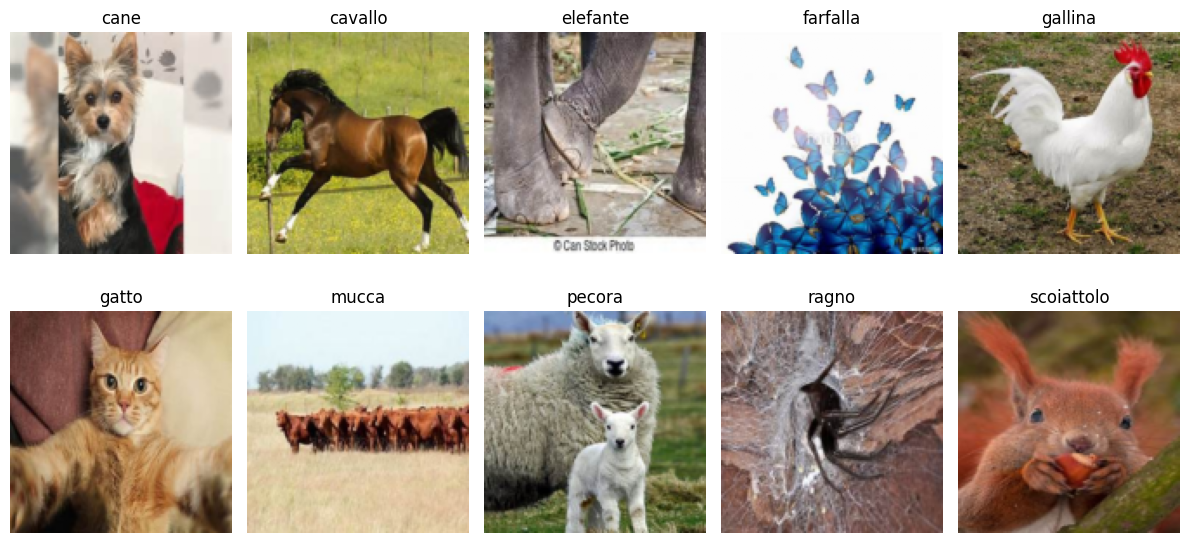

In [5]:
import matplotlib.pyplot as plt
import numpy as np


class_names = full_dataset.classes

class_images = {i: None for i in range(len(class_names))}


for img, label in full_dataset:
    if class_images[label] is None:
        class_images[label] = img
    if all(v is not None for v in class_images.values()):
        break

plt.figure(figsize=(12, 6))

for i, (label, img) in enumerate(class_images.items()):
    plt.subplot(2, 5, i + 1)

    img_np = img.permute(1, 2, 0).numpy()

    plt.imshow(img_np)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Start a model

In [12]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import Trainer, TrainingArguments
import torch

classes = ["dog", "horse", "elephant", "butterfly", "chicken",
           "cat", "cow", "sheep", "spider", "squirrel"]

model_name = "distilbert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(model_name)

# Templates for generating synthetic datasets
templates = [
    "There is a {} in the picture",
    "I see a {}",
    "This {} is big",
    "The {} is here",
    "Look at that {}",
    "A {} is running",
    "Do you see the {}?",
    "I think it is a {}",
    "This looks like a {}",
    "It seems to be a {}",
    "Probably a {}",
    "The animal is a {}",
    "This picture shows a {}",
    "That must be a {}",
    "In the image there is a {}",
    "It is a {}",
    "It's a {}",
    "That is a {}",
    "That's a {}",
    "Here is a {}",
    "Here’s a {}",
    "This is a {}",
]


texts  = []
labels = []
# Sentence and label generation:
# 1 means "this is the name of an animal," 0 means a regular word
for animal in classes:
    for t in templates:
        sentence = t.format(animal)
        words    = sentence.split()
        label    = [1 if w.strip(".,?") == animal else 0 for w in words]
        texts.append(sentence)
        labels.append(label)

# dataset
class AnimalDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts, truncation=True, padding=True)
        self.labels    = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # We need to assign a label only to the first sub-token of the word.
        word_ids    = self.encodings.word_ids(batch_index=idx)
        word_labels = self.labels[idx]
        aligned     = []
        prev_word_id = None

        for word_id in word_ids:
            if word_id is None:
                # Special tokens ([CLS], [SEP], [PAD]) are ignored when calculating losses (-100)
                aligned.append(-100)
            elif word_id != prev_word_id:
                # This is the first sub-token of the new word—let's assign it a real label
                aligned.append(word_labels[word_id] if word_id < len(word_labels) else -100)
            else:
                # Subsequent sub-tokens of the same word are ignored (-100)
                aligned.append(-100)
            prev_word_id = word_id

        item["labels"] = torch.tensor(aligned, dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = AnimalDataset(texts, labels, tokenizer)

# Creating a model
# num_labels=2 (0: not an animal, 1: an animal)
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=2,
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    logging_steps=10,
    save_steps=50,
)
# Using Hugging Face Trainer to Simplify the Training Process
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)

trainer.train()

model.save_pretrained("ner_model")
tokenizer.save_pretrained("ner_model")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('ner_model/tokenizer_config.json', 'ner_model/tokenizer.json')

In [15]:
import json

idx_to_class = {
    0: "cane",
    1: "cavallo",
    2: "elefante",
    3: "farfalla",
    4: "gallina",
    5: "gatto",
    6: "mucca",
    7: "pecora",
    8: "ragno",
    9: "scoiattolo"
}

with open("idx_to_class.json", "w") as f:
    json.dump(idx_to_class, f)

## Testing

In [16]:
from pipeline import check_text_image_match

### True text and photo

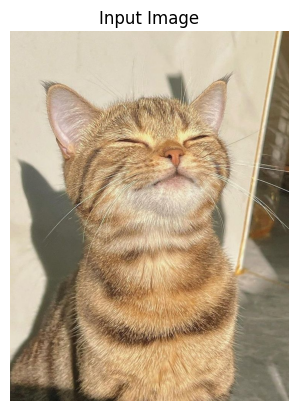

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "cat.jpg"

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [18]:
check_text_image_match(
    "There is a cat in the picture",
    "cat.jpg"
)

Text animal: cat
Image animal: cat


True

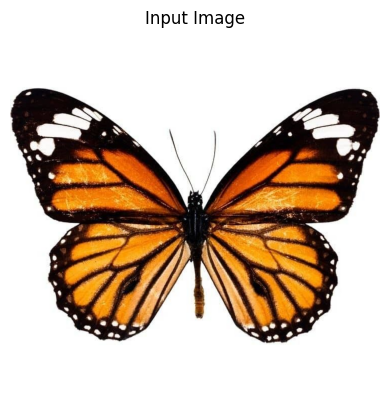

In [20]:
image_path = "Butterfly.jpg"

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [21]:
check_text_image_match(
    "Look! It's a butterfly",
    "Butterfly.jpg"
)

Text animal: butterfly
Image animal: butterfly


True

### False text and true photo

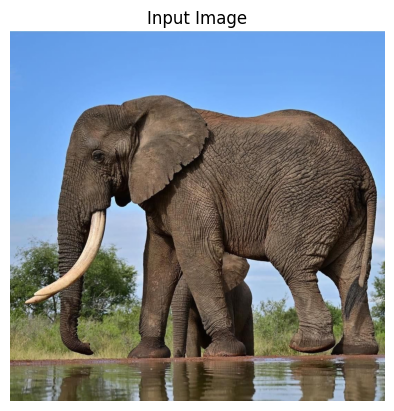

In [22]:
image_path = "elephant.jpg"

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [23]:
check_text_image_match(
    "What a beautiful dog",
    "elephant.jpg"
)

Text animal: dog
Image animal: elephant


False

### Where the model made a mistake

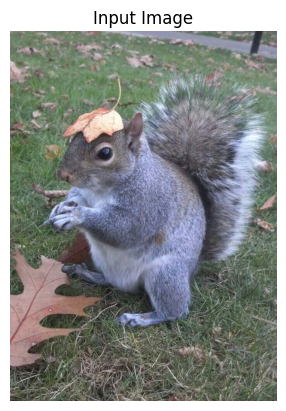

In [24]:
image_path = "squirrel.jpg"

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [25]:
check_text_image_match(
    "It's a squirrel ",
    "squirrel.jpg"
)

Text animal: squirrel
Image animal: chicken


False

So, the model recognised it as a chicken

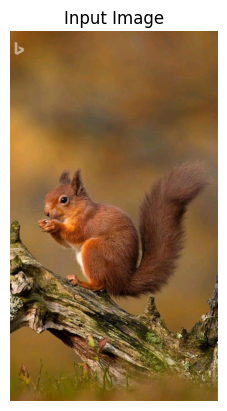

In [26]:
image_path = "squirrel2.jpg"

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [27]:
check_text_image_match(
    "It's a squirrel ",
    "squirrel2.jpg"
)

Text animal: squirrel
Image animal: squirrel


True

But here we have the correct answer!